# 数据审计与描述性分析（Day 1 / 阶段 2 数据审计）

对 `data/raw/训练集.csv` 与 `data/raw/测试集_X.csv` 做完整审计：规模、日期、缺失、重复、价格与成交异常、涨跌停、标签分布与标签定义验证。官方口径（来自 `docs/data_dictionary.md`）：

| 数据 | 官方行数 | 官方股票数 | 官方日期范围 | 官方标签缺失 |
| --- | ---: | ---: | --- | --- |
| 训练集 | 7,900,350 | 4650 | 20180102—20241231 | 约 14.5% |
| 测试集_X | 1,599,600 | 4650 | 20250102—20260608 | — |

路径统一从 `configs/project.yaml` 读取，产物写入 `data/processed/` 与 `outputs/figures/`。原始数据只读不改。

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
with open(ROOT / "configs" / "project.yaml", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)
TRAIN_PATH = ROOT / CFG["paths"]["train"]
TEST_PATH = ROOT / CFG["paths"]["test_x"]
FIG_DIR = ROOT / CFG["paths"]["figures"]
PROC_DIR = ROOT / CFG["paths"]["processed"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)
print("train:", TRAIN_PATH.relative_to(ROOT), "test:", TEST_PATH.relative_to(ROOT))

train: data\raw\训练集.csv test: data\raw\测试集_X.csv


## 1. 训练集规模核对

In [2]:
%%time
train = pd.read_csv(
    TRAIN_PATH,
    dtype={"ts_code": "category", "trade_date": "int32",
           "open": "float64", "high": "float64", "low": "float64", "close": "float64",
           "vol": "float64", "amount": "float64",
           "flag_limit_up": "int8", "flag_limit_down": "int8", "y_ret_1d": "float64"},
)
print(train.dtypes)
print(f"内存占用: {train.memory_usage(deep=True).sum() / 1e6:,.0f} MB")

ts_code            category
trade_date            int32
open                float64
high                float64
low                 float64
close               float64
vol                 float64
amount              float64
flag_limit_up          int8
flag_limit_down        int8
y_ret_1d            float64
dtype: object
内存占用: 506 MB
CPU times: total: 4.7 s
Wall time: 4.74 s


In [3]:
official = {
    "行数": (7_900_350, len(train)),
    "股票数": (4_650, train["ts_code"].nunique()),
    "交易日数": (None, train["trade_date"].nunique()),
    "日期起点": ("20180102", str(train["trade_date"].min())),
    "日期终点": ("20241231", str(train["trade_date"].max())),
}
rows = []
for k, (o, a) in official.items():
    rows.append({"项目": k, "官方口径": o if o is not None else "—", "实测": a,
                 "一致": "—" if o is None else ("是" if str(o) == str(a) else "否")})
pd.DataFrame(rows)

,项目,官方口径,实测,一致
0,行数,7900350,7900350,是
1,股票数,4650,4650,是
2,交易日数,—,1699,—
3,日期起点,20180102,20180102,是
4,日期终点,20241231,20241231,是


## 2. 年度分布

In [4]:
train["year"] = (train["trade_date"] // 10_000).astype("int32")
train_yearly = train.groupby("year", observed=True).agg(
    rows=("ts_code", "size"),
    n_stocks=("ts_code", "nunique"),
    n_days=("trade_date", "nunique"),
    y_missing_ratio=("y_ret_1d", lambda s: s.isna().mean()),
    y_mean=("y_ret_1d", "mean"),
    limit_up_ratio=("flag_limit_up", "mean"),
    limit_down_ratio=("flag_limit_down", "mean"),
    vol0_ratio=("vol", lambda s: (s == 0).mean()),
)
train_yearly

,rows,n_stocks,n_days,y_missing_ratio,y_mean,limit_up_ratio,limit_down_ratio,vol0_ratio
year,,,,,,,,
2018,1129950,4650,243,0.262292,-0.001306,0.010909,0.006486,0.030713
2019,1134600,4650,244,0.238238,0.001303,0.013154,0.004530,0.002249
2020,1129950,4650,243,0.203475,0.000862,0.016683,0.007358,0.001073
2021,1129950,4650,243,0.137000,0.001018,0.017472,0.004744,0.000000
2022,1125300,4650,242,0.085562,-0.000216,0.015801,0.005395,0.000000
2023,1125300,4650,242,0.055886,0.000236,0.008857,0.003029,0.000000
2024,1125300,4650,242,0.027766,0.000329,0.018329,0.009542,0.000000


## 3. 缺失审计

In [5]:
na_counts = train[["open", "high", "low", "close", "vol", "amount",
                          "flag_limit_up", "flag_limit_down", "y_ret_1d"]].isna().sum()
pd.DataFrame({"缺失数": na_counts, "缺失率": na_counts / len(train)})

,缺失数,缺失率
open,1139980,0.144295
high,1139980,0.144295
low,1139980,0.144295
close,1139980,0.144295
vol,1139940,0.144290
amount,1139940,0.144290
flag_limit_up,0,0.000000
flag_limit_down,0,0.000000
y_ret_1d,1141819,0.144528


In [6]:
y_na_total = train["y_ret_1d"].isna()
print(f"y_ret_1d 总缺失: {y_na_total.sum():,} 行, 缺失率 {y_na_total.mean():.4%}（官方口径约 14.5%）")

# 逐股票缺失比例分布
miss_by_stock = train.groupby("ts_code", observed=True)["y_ret_1d"].apply(lambda s: s.isna().mean())
print("\n逐股票 y 缺失比例分布:")
print(miss_by_stock.describe())

y_ret_1d 总缺失: 1,141,819 行, 缺失率 14.4528%（官方口径约 14.5%）



逐股票 y 缺失比例分布:
count   4,650.000000
mean        0.144528
std         0.260177
min         0.000000
25%         0.000000
50%         0.000000
75%         0.204679
max         1.000000
Name: y_ret_1d, dtype: float64


## 4. 重复键检查

In [7]:
dup_mask = train.duplicated(subset=["ts_code", "trade_date"], keep=False)
print(f"ts_code + trade_date 重复行: {dup_mask.sum():,}")
if dup_mask.any():
    print(train.loc[dup_mask].head(20))

ts_code + trade_date 重复行: 0


## 5. 价格与成交异常

In [8]:
anomaly = {
    "close<=0": (train["close"] <= 0).sum(),
    "open<=0": (train["open"] <= 0).sum(),
    "high<low": (train["high"] < train["low"]).sum(),
    "high<max(open,close)": (train["high"] < train[["open", "close"]].max(axis=1)).sum(),
    "low>min(open,close)": (train["low"] > train[["open", "close"]].min(axis=1)).sum(),
    "vol==0": (train["vol"] == 0).sum(),
    "amount==0": (train["amount"] == 0).sum(),
    "vol==0 且 amount==0": ((train["vol"] == 0) & (train["amount"] == 0)).sum(),
    "vol==0 但 amount>0": ((train["vol"] == 0) & (train["amount"] > 0)).sum(),
    "vol>0 但 amount==0": ((train["vol"] > 0) & (train["amount"] == 0)).sum(),
}
anom = pd.DataFrame({"行数": pd.Series(anomaly), "占比": pd.Series(anomaly) / len(train)})
anom

,行数,占比
close<=0,0,0.000000
open<=0,0,0.000000
high<low,0,0.000000
"high<max(open,close)",0,0.000000
"low>min(open,close)",0,0.000000
vol==0,38468,0.004869
amount==0,38468,0.004869
vol==0 且 amount==0,38468,0.004869
vol==0 但 amount>0,0,0.000000
vol>0 但 amount==0,0,0.000000


In [9]:
# vol==0 行的标签缺失情况：验证“零成交 ≈ 停牌 → 无次日收益”的猜测
vol0 = train["vol"] == 0
print(f"vol==0 行中 y 缺失率: {train.loc[vol0, 'y_ret_1d'].isna().mean():.4%}")
print(f"vol>0 行中 y 缺失率: {train.loc[~vol0, 'y_ret_1d'].isna().mean():.4%}")
print(f"y 缺失行中 vol==0 的比例: {(train.loc[train['y_ret_1d'].isna(), 'vol'] == 0).mean():.4%}")

vol==0 行中 y 缺失率: 0.0234%
vol>0 行中 y 缺失率: 14.5234%
y 缺失行中 vol==0 的比例: 0.0008%


## 6. 涨跌停统计

In [10]:
print(f"涨停行占比: {train['flag_limit_up'].mean():.4%}")
print(f"跌停行占比: {train['flag_limit_down'].mean():.4%}")
print(f"同日既涨停又跌停: {((train['flag_limit_up'] == 1) & (train['flag_limit_down'] == 1)).sum()}")
print(f"flag 取值集合: up={sorted(train['flag_limit_up'].unique())}, down={sorted(train['flag_limit_down'].unique())}")
train_yearly[["limit_up_ratio", "limit_down_ratio"]]

涨停行占比: 1.4458%
跌停行占比: 0.5868%
同日既涨停又跌停: 4
flag 取值集合: up=[np.int8(0), np.int8(1)], down=[np.int8(0), np.int8(1)]


,limit_up_ratio,limit_down_ratio
year,,
2018,0.010909,0.006486
2019,0.013154,0.004530
2020,0.016683,0.007358
2021,0.017472,0.004744
2022,0.015801,0.005395
2023,0.008857,0.003029
2024,0.018329,0.009542


## 7. 标签分析与定义验证

In [11]:
y = train["y_ret_1d"]
print(y.describe())
print(f"偏度: {y.skew():.4f}, 峰度: {y.kurt():.4f}")
print(f"|y|>0.1 的行数: {(y.abs() > 0.1).sum():,}, |y|>0.2 的行数: {(y.abs() > 0.2).sum():,}")

count   6,758,531.000000
mean            0.000325
std             0.029870
min            -0.644796
25%            -0.014493
50%             0.000000
75%             0.013216
max             2.574250
Name: y_ret_1d, dtype: float64
偏度: 0.6469, 峰度: 13.4304


|y|>0.1 的行数: 88,289, |y|>0.2 的行数: 2,892


In [12]:
%%time
# 验证官方标签定义: y_ret_1d == close(t+1)/close(t) - 1（按股票、按日期排序后向前看一天）
train_sorted = train.sort_values(["ts_code", "trade_date"], kind="stable")
next_close = train_sorted.groupby("ts_code", observed=True)["close"].shift(-1)
expected_y = next_close / train_sorted["close"] - 1
actual_y = train_sorted["y_ret_1d"]

cmp_mask = actual_y.notna() & expected_y.notna()
diff = (actual_y[cmp_mask] - expected_y[cmp_mask]).abs()
print(f"可比较行数: {cmp_mask.sum():,}")
print(f"差异 > 1e-6 的行数: {(diff > 1e-6).sum():,}（占可比行 {(diff > 1e-6).mean():.4%}）")
print(f"最大绝对差异: {diff.max():.3e}")

# y 非 NaN 但下一行是另一只股票（定义失效）或不存在（末日）的行
last_row = expected_y.isna()
print(f"y 非 NaN 但无次日记录: {(actual_y.notna() & last_row).sum():,}")
# 训练集最后一交易日 y 是否全为 NaN
last_day = train_sorted["trade_date"].max()
print(f"最后一交易日({last_day}) y 非 NaN 行数: "
      f"{train_sorted.loc[train_sorted['trade_date'] == last_day, 'y_ret_1d'].notna().sum():,}")

可比较行数: 6,754,006
差异 > 1e-6 的行数: 0（占可比行 0.0000%）
最大绝对差异: 7.563e-16
y 非 NaN 但无次日记录: 4,525
最后一交易日(20241231) y 非 NaN 行数: 4,525
CPU times: total: 656 ms
Wall time: 514 ms


## 8. 测试集审计

In [13]:
%%time
test = pd.read_csv(
    TEST_PATH,
    dtype={"ts_code": "category", "trade_date": "int32",
           "open": "float64", "high": "float64", "low": "float64", "close": "float64",
           "vol": "float64", "amount": "float64",
           "flag_limit_up": "int8", "flag_limit_down": "int8"},
)
test["year"] = (test["trade_date"] // 10_000).astype("int32")
test_summary = {
    "行数": (1_599_600, len(test)),
    "股票数": (4_650, test["ts_code"].nunique()),
    "日期起点": ("20250102", str(test["trade_date"].min())),
    "日期终点": ("20260608", str(test["trade_date"].max())),
    "交易日数": (None, test["trade_date"].nunique()),
}
pd.DataFrame([{"项目": k, "官方口径": o if o is not None else "—", "实测": a,
               "一致": "—" if o is None else ("是" if str(o) == str(a) else "否")}
              for k, (o, a) in test_summary.items()])

CPU times: total: 844 ms
Wall time: 890 ms


,项目,官方口径,实测,一致
0,行数,1599600,1599600,是
1,股票数,4650,4650,是
2,日期起点,20250102,20250102,是
3,日期终点,20260608,20260608,是
4,交易日数,—,344,—


In [14]:
test_yearly = test.groupby("year", observed=True).agg(
    rows=("ts_code", "size"),
    n_stocks=("ts_code", "nunique"),
    n_days=("trade_date", "nunique"),
    limit_up_ratio=("flag_limit_up", "mean"),
    limit_down_ratio=("flag_limit_down", "mean"),
    vol0_ratio=("vol", lambda s: (s == 0).mean()),
)
test_yearly

,rows,n_stocks,n_days,limit_up_ratio,limit_down_ratio,vol0_ratio
year,,,,,,
2025,1129950,4650,243,0.015910,0.006210,0.000000
2026,469650,4650,101,0.017490,0.005745,0.000000


In [15]:
test_na = test[["open", "high", "low", "close", "vol", "amount",
                     "flag_limit_up", "flag_limit_down"]].isna().sum()
print("测试集缺失数:\n", test_na)
print(f"测试集重复键行数: {test.duplicated(subset=['ts_code', 'trade_date'], keep=False).sum():,}")
print(f"测试集 vol==0: {(test['vol'] == 0).sum():,}, amount==0: {(test['amount'] == 0).sum():,}")
print(f"测试集 close<=0: {(test['close'] <= 0).sum():,}, high<low: {(test['high'] < test['low']).sum():,}")

测试集缺失数:
 open               44844
high               44844
low                44844
close              44844
vol                44831
amount             44831
flag_limit_up          0
flag_limit_down        0
dtype: int64


测试集重复键行数: 0
测试集 vol==0: 0, amount==0: 0
测试集 close<=0: 0, high<low: 0


## 9. 训练/测试交叉检查

In [16]:
train_stocks = set(train["ts_code"].cat.categories)
test_stocks = set(test["ts_code"].cat.categories)
print(f"训练集股票数: {len(train_stocks)}, 测试集股票数: {len(test_stocks)}")
print(f"测试集独有（训练期未出现）: {len(test_stocks - train_stocks)}")
print(f"训练集独有（测试期已退出）: {len(train_stocks - test_stocks)}")
print(f"训练集最后交易日: {train['trade_date'].max()}, 测试集首个交易日: {test['trade_date'].min()}")
print(f"日期无重叠: {train['trade_date'].max() < test['trade_date'].min()}")
print(f"测试期日均股票数: {len(test) / test['trade_date'].nunique():,.0f}")

训练集股票数: 4650, 测试集股票数: 4650
测试集独有（训练期未出现）: 0
训练集独有（测试期已退出）: 0
训练集最后交易日: 20241231, 测试集首个交易日: 20250102
日期无重叠: True
测试期日均股票数: 4,650


## 10. 图表

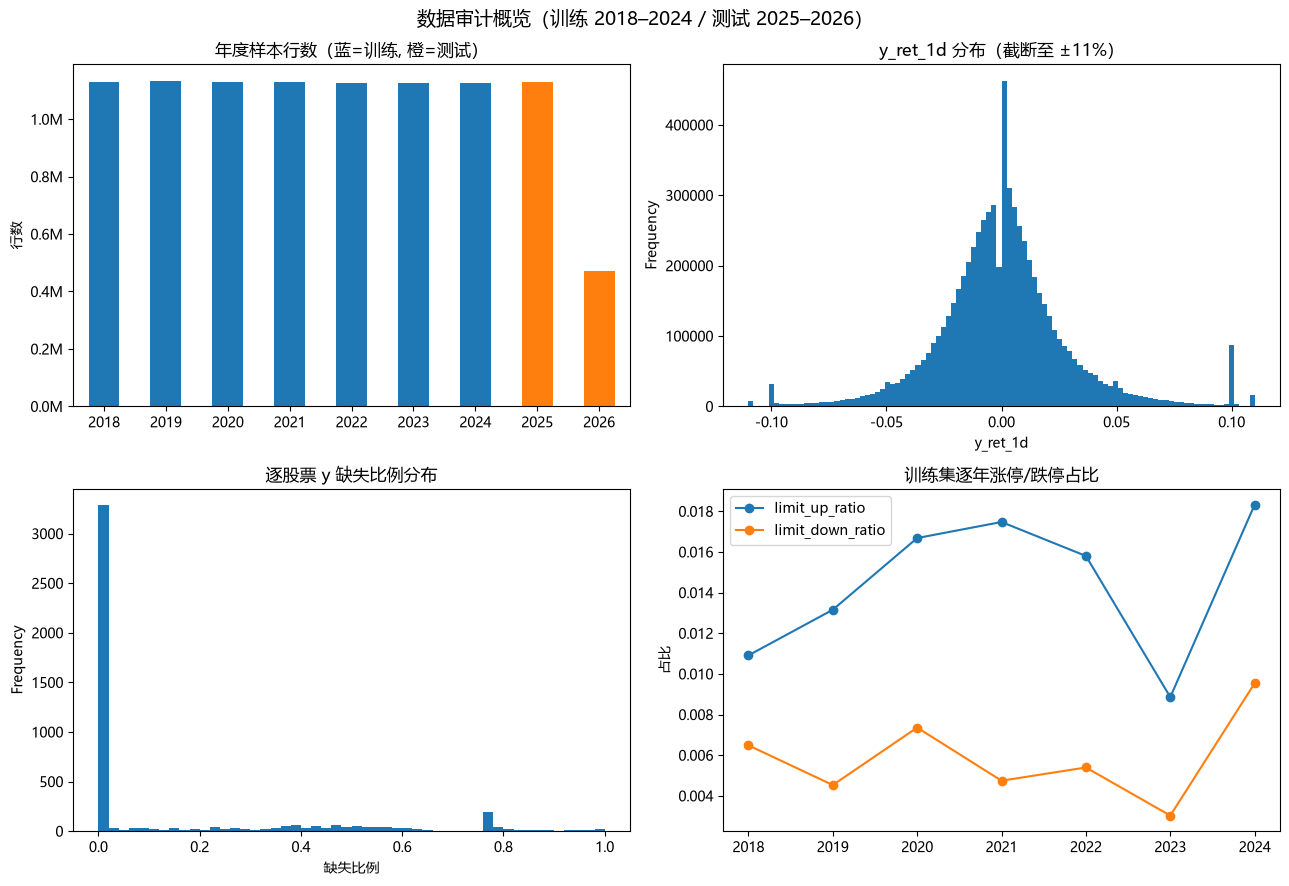

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
yearly_rows = pd.concat([train_yearly["rows"], test_yearly["rows"]])
colors = ["#1f77b4"] * len(train_yearly) + ["#ff7f0e"] * len(test_yearly)
yearly_rows.plot.bar(ax=ax, color=colors)
ax.set_title("年度样本行数（蓝=训练, 橙=测试）")
ax.set_xlabel(""); ax.set_ylabel("行数")
ax.tick_params(axis="x", rotation=0)
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1e6:.1f}M")

ax = axes[0, 1]
y.dropna().clip(-0.11, 0.11).plot.hist(bins=100, ax=ax)
ax.set_title("y_ret_1d 分布（截断至 ±11%）")
ax.set_xlabel("y_ret_1d")

ax = axes[1, 0]
miss_by_stock.plot.hist(bins=50, ax=ax)
ax.set_title("逐股票 y 缺失比例分布")
ax.set_xlabel("缺失比例")

ax = axes[1, 1]
train_yearly[["limit_up_ratio", "limit_down_ratio"]].plot(ax=ax, marker="o")
ax.set_title("训练集逐年涨停/跌停占比")
ax.set_xlabel(""); ax.set_ylabel("占比")

fig.suptitle("数据审计概览（训练 2018–2024 / 测试 2025–2026）", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. 汇总产物保存

In [18]:
train_yearly_out = train_yearly.reset_index()
train_yearly_out.to_csv(PROC_DIR / "eda_train_yearly.csv", index=False, encoding="utf-8-sig")
test_yearly.reset_index().to_csv(PROC_DIR / "eda_test_yearly.csv", index=False, encoding="utf-8-sig")

summary = {
    "train": {
        "rows": int(len(train)),
        "n_stocks": int(train["ts_code"].nunique()),
        "n_days": int(train["trade_date"].nunique()),
        "date_min": int(train["trade_date"].min()),
        "date_max": int(train["trade_date"].max()),
        "y_missing_rows": int(train["y_ret_1d"].isna().sum()),
        "y_missing_ratio": float(train["y_ret_1d"].isna().mean()),
        "y_missing_ratio_by_stock_mean": float(miss_by_stock.mean()),
        "y_missing_ratio_by_stock_max": float(miss_by_stock.max()),
        "duplicate_key_rows": int(dup_mask.sum()),
        "ohlcv_nan": {c: int(n) for c, n in na_counts.items() if c != "y_ret_1d"},
        "vol0_rows": int((train["vol"] == 0).sum()),
        "amount0_rows": int((train["amount"] == 0).sum()),
        "vol0_y_missing_ratio": float(train.loc[train["vol"] == 0, "y_ret_1d"].isna().mean()),
        "vol_pos_y_missing_ratio": float(train.loc[train["vol"] != 0, "y_ret_1d"].isna().mean()),
        "limit_up_ratio": float(train["flag_limit_up"].mean()),
        "limit_down_ratio": float(train["flag_limit_down"].mean()),
        "y_mean": float(train["y_ret_1d"].mean()),
        "y_std": float(train["y_ret_1d"].std()),
        "y_min": float(train["y_ret_1d"].min()),
        "y_max": float(train["y_ret_1d"].max()),
        "label_definition_mismatch_rows_gt_1e6": int((diff > 1e-6).sum()),
        "label_definition_max_abs_diff": float(diff.max()),
    },
    "test": {
        "rows": int(len(test)),
        "n_stocks": int(test["ts_code"].nunique()),
        "n_days": int(test["trade_date"].nunique()),
        "date_min": int(test["trade_date"].min()),
        "date_max": int(test["trade_date"].max()),
        "duplicate_key_rows": int(test.duplicated(subset=["ts_code", "trade_date"], keep=False).sum()),
        "vol0_rows": int((test["vol"] == 0).sum()),
        "limit_up_ratio": float(test["flag_limit_up"].mean()),
        "limit_down_ratio": float(test["flag_limit_down"].mean()),
        "stocks_not_in_train": int(len(test_stocks - train_stocks)),
    },
}
with open(PROC_DIR / "eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("已保存: data/processed/eda_train_yearly.csv, eda_test_yearly.csv, eda_summary.json")
print("已保存: outputs/figures/eda_overview.png")
summary

已保存: data/processed/eda_train_yearly.csv, eda_test_yearly.csv, eda_summary.json
已保存: outputs/figures/eda_overview.png


{'train': {'rows': 7900350,
  'n_stocks': 4650,
  'n_days': 1699,
  'date_min': 20180102,
  'date_max': 20241231,
  'y_missing_rows': 1141819,
  'y_missing_ratio': 0.14452764750928757,
  'y_missing_ratio_by_stock_mean': 0.1445276475092876,
  'y_missing_ratio_by_stock_max': 1.0,
  'duplicate_key_rows': 0,
  'ohlcv_nan': {'open': 1139980,
   'high': 1139980,
   'low': 1139980,
   'close': 1139980,
   'vol': 1139940,
   'amount': 1139940,
   'flag_limit_up': 0,
   'flag_limit_down': 0},
  'vol0_rows': 38468,
  'amount0_rows': 38468,
  'vol0_y_missing_ratio': 0.00023396069460330664,
  'vol_pos_y_missing_ratio': 0.14523367305690926,
  'limit_up_ratio': 0.014457587322080667,
  'limit_down_ratio': 0.005868094451511642,
  'y_mean': 0.00032452508295153853,
  'y_std': 0.02986993369089558,
  'y_min': -0.6447962808648744,
  'y_max': 2.574249605055292,
  'label_definition_mismatch_rows_gt_1e6': 0,
  'label_definition_max_abs_diff': 7.563394355258879e-16},
 'test': {'rows': 1599600,
  'n_stocks': 46

## 结论

1. **规模与官方口径完全一致**：训练 7,900,350 行 / 4,650 只 / 20180102–20241231；测试 1,599,600 行 / 4,650 只 / 20250102–20260608。且是**完全平衡面板**：4650 × 1699 = 7,900,350，4650 × 344 = 1,599,600——每只股票每个交易日都有一行，未上市/停牌以 NaN 价格行出现。
2. **标签缺失 14.4528%**，与官方约 14.5% 一致；逐年递减（2018 年 26.2% → 2024 年 2.8%），主因是早年大量股票未上市。缺失机制与价格 NaN 绑定：当日或次日价格缺失即无标签；与 vol==0 基本无关（vol==0 行标签缺失率仅 0.02%）。
3. **无重复键、无价格异常**（close<=0 / high<low 等全为 0）；vol==0 与 amount==0 完全重合，共 38,468 行（0.49%），集中在 2018–2020。
4. **标签定义验证通过**：y_ret_1d 与 close(t+1)/close(t)-1 在全部可比 6,754,006 行上完全一致（最大差 7.6e-16）。边界发现：20241231 有 4,525 行 y 非 NaN，由测试期 20250102 收盘价计算而来，训练时可用。
5. **标签有重尾**：std 2.99%，min -64.5%，max +257.4%，峰度 13.4；|y|>0.1 共 88,289 行（长期停牌复牌、新股等）。树模型可直接用；线性模型参与融合时需考虑截尾。
6. **测试集有 44,844 行（2.80%）价格缺失**（未上市/停牌），提交必须覆盖这些键，需要兜底预测策略（如填 0 / 截面中位数）。

详细表格与处理建议见 docs/data_audit_report.md。